In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv('/content/drive/MyDrive/heart (2).csv')

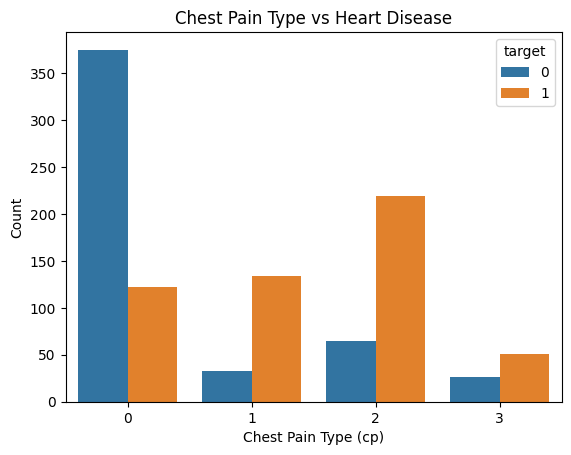

In [69]:
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Count')
plt.show()


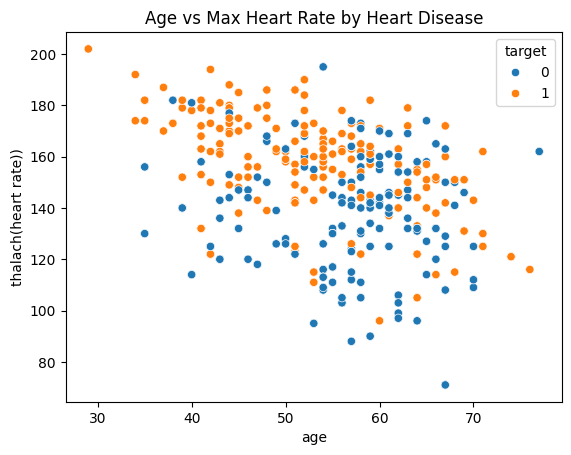

In [70]:
sns.scatterplot(x='age', y='thalach(heart rate))', hue='target', data=df)
plt.title('Age vs Max Heart Rate by Heart Disease')
plt.show()

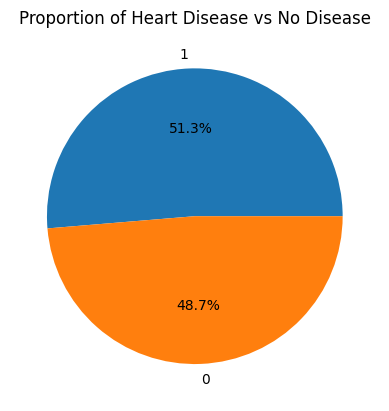

In [72]:
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Proportion of Heart Disease vs No Disease')
plt.show()


In [73]:
# Separating variables from outcome(s)
X = df.drop('target', axis=1) # Variables
Y = df.target.values # Outcome

In [75]:
Y

array([0, 0, 0, ..., 0, 1, 0])

In [76]:
# Normalizing all the variables
from sklearn import preprocessing

X = X.values # It will return a numpy array
min_max_scaler = preprocessing.MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X)
df = pd.DataFrame(X_scaled)
df


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.479167,1.0,0.000000,0.292453,0.196347,0.0,0.5,0.740458,0.0,0.161290,1.0,0.50,1.000000
1,0.500000,1.0,0.000000,0.433962,0.175799,1.0,0.0,0.641221,1.0,0.500000,0.0,0.00,1.000000
2,0.854167,1.0,0.000000,0.481132,0.109589,0.0,0.5,0.412214,1.0,0.419355,0.0,0.00,1.000000
3,0.666667,1.0,0.000000,0.509434,0.175799,0.0,0.5,0.687023,0.0,0.000000,1.0,0.25,1.000000
4,0.687500,0.0,0.000000,0.415094,0.383562,1.0,0.5,0.267176,0.0,0.306452,0.5,0.75,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.625000,1.0,0.333333,0.433962,0.216895,0.0,0.5,0.709924,1.0,0.000000,1.0,0.00,0.666667
1021,0.645833,1.0,0.000000,0.292453,0.301370,0.0,0.0,0.534351,1.0,0.451613,0.5,0.25,1.000000
1022,0.375000,1.0,0.000000,0.150943,0.340183,0.0,0.0,0.358779,1.0,0.161290,0.5,0.25,0.666667
1023,0.437500,0.0,0.000000,0.150943,0.292237,0.0,0.0,0.671756,0.0,0.000000,1.0,0.00,0.666667


In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [80]:
from sklearn.model_selection import KFold
cv_data = KFold(n_splits=5, shuffle=True, random_state=42)

In [82]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import numpy as np


In [90]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold


cv_data = KFold(n_splits=5, random_state=1, shuffle=True)

results_NB = cross_validate(GaussianNB(), X, Y, cv=cv_data, scoring=['accuracy'], return_train_score=True)

results_DT = cross_validate(DecisionTreeClassifier(), X, Y, cv=cv_data, scoring=['accuracy'], return_train_score=True)

print("Accuracy score on the Train set using NB:", np.around(results_NB['train_accuracy'], 2))
print("Mean Accuracy score on the Train set using NB: %.2f"% results_NB['train_accuracy'].mean())
print("\nAccuracy score on Test set using NB:", np.around(results_NB['test_accuracy'], 3))
print("Mean Accuracy score on the Test set using NB: %.2f" %results_NB['test_accuracy'].mean())

print("\n")

print("\nAccuracy score on the Train set using DT:", np.around(results_DT['train_accuracy'], 2))
print("Mean Accuracy score on the Train set using DT: %.2f"% results_DT['train_accuracy'].mean())
print("\nAccuracy score on Test set using DT:", np.around(results_DT['test_accuracy'], 3))
print("Mean Accuracy score on the Test set using DT: %.2f" %results_DT['test_accuracy'].mean())

Accuracy score on the Train set using NB: [0.84 0.83 0.82 0.82 0.83]
Mean Accuracy score on the Train set using NB: 0.83

Accuracy score on Test set using NB: [0.78  0.805 0.839 0.844 0.834]
Mean Accuracy score on the Test set using NB: 0.82



Accuracy score on the Train set using DT: [1. 1. 1. 1. 1.]
Mean Accuracy score on the Train set using DT: 1.00

Accuracy score on Test set using DT: [1. 1. 1. 1. 1.]
Mean Accuracy score on the Test set using DT: 1.00
